# Brazilian Used Car Price Prediction (FIPE Dataset)
**Author:** Matheus Paixão  
**Domain:** Automotive Market Analytics & Predictive Modeling  
**Stack:** Python, Pandas, Seaborn, Scikit-Learn, XGBoost

## 1. Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## 2. Exploratory Data Analysis (EDA)

### a. Load Dataset ()

In [2]:
carros = pd.read_csv('precos_carros_brasil.csv')

### b. Check for Missing Values & Data Cleaning

In [3]:
# verificando se há valores nulos
carros.isna().sum()

year_of_reference     65245
month_of_reference    65245
fipe_code             65245
authentication        65245
brand                 65245
model                 65245
fuel                  65245
gear                  65245
engine_size           65245
year_model            65245
avg_price_brl         65245
dtype: int64

In [4]:
# contando em quantas linhas todos os valores sao nulos
carros.isna().all(axis=1).sum()
# isso significa que todos os 65245 valores nulos, são nulos em todas as colunas. Então, podemos excluir essas linhas.

np.int64(65245)

In [5]:
# excluindo linhas com todos os valores nulos
carros = carros.dropna(how='all')

In [6]:
# verificando se há valores nulos novamente
carros.isna().sum()

year_of_reference     0
month_of_reference    0
fipe_code             0
authentication        0
brand                 0
model                 0
fuel                  0
gear                  0
engine_size           0
year_model            0
avg_price_brl         0
dtype: int64

### c. Check and Remove Duplicate Records

In [7]:
# verificando se há valores duplicados
carros.duplicated().sum()

np.int64(2)

In [8]:
# excluindo as linhas com valores duplicados
carros = carros.drop_duplicates()

### d. Separate Numerical & Categorical Features and Generate Summary Statistics

In [9]:
numericas_cols = [col for col in carros.columns if carros[col].dtype != 'object']
categoricas_cols = [col for col in carros.columns if carros[col].dtype == 'object']

In [10]:
carros[numericas_cols].describe()

,year_of_reference,year_model,avg_price_brl
count,202295.000000,202295.000000,202295.000000
mean,2021.564695,2011.271514,52756.765713
std,0.571904,6.376241,51628.912116
min,2021.000000,2000.000000,6647.000000
25%,2021.000000,2006.000000,22855.000000
50%,2022.000000,2012.000000,38027.000000
75%,2022.000000,2016.000000,64064.000000
max,2023.000000,2023.000000,979358.000000


In [11]:
carros[categoricas_cols].describe()

,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size
count,202295,202295,202295,202295,202295,202295,202295,202295
unique,12,2091,202295,6,2112,3,2,29
top,January,003281-6,7hbnjmj9z5dqw,Fiat,Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p,Gasoline,manual,"1,6"
freq,24260,425,1,44962,425,168684,161883,47420


### e. Value Counts by Car Model and Brand

In [12]:
# Contagem de valores por modelo
carros['model'].value_counts()

model
Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p     425
Palio Week. Adv/Adv TRYON 1.8 mpi Flex    425
Focus 2.0 16V/SE/SE Plus Flex 5p Aut.     400
Saveiro 1.6 Mi/ 1.6 Mi Total Flex 8V      400
Doblo Adv/Adv TRYON/LOCKER 1.8 Flex       375
                                         ... 
Polo Track 1.0 Flex 12V 5p                  2
STEPWAY Zen Flex 1.0 12V Mec.               2
Saveiro Robust 1.6 Total Flex 16V CD        2
Saveiro Robust 1.6 Total Flex 16V           2
Gol Last Edition 1.0 Flex 12V 5p            2
Name: count, Length: 2112, dtype: int64

In [13]:
# Contagem de valores por marca
carros['brand'].value_counts()

brand
Fiat               44962
VW - VolksWagen    44312
GM - Chevrolet     38590
Ford               33150
Renault            29191
Nissan             12090
Name: count, dtype: int64

### f. EDA Key Insights

A total of 65,245 completely null rows were identified and removed, along with 2 duplicate rows. The cleaned dataset consists of 3 numerical columns (, , ) and 8 categorical variables (, , , , , , , ).

## 3. Data Visualization

### a. Distribution of Vehicles by Brand

[Text(0, 0, '44962'),
 Text(0, 0, '44312'),
 Text(0, 0, '38590'),
 Text(0, 0, '33150'),
 Text(0, 0, '29191'),
 Text(0, 0, '12090')]

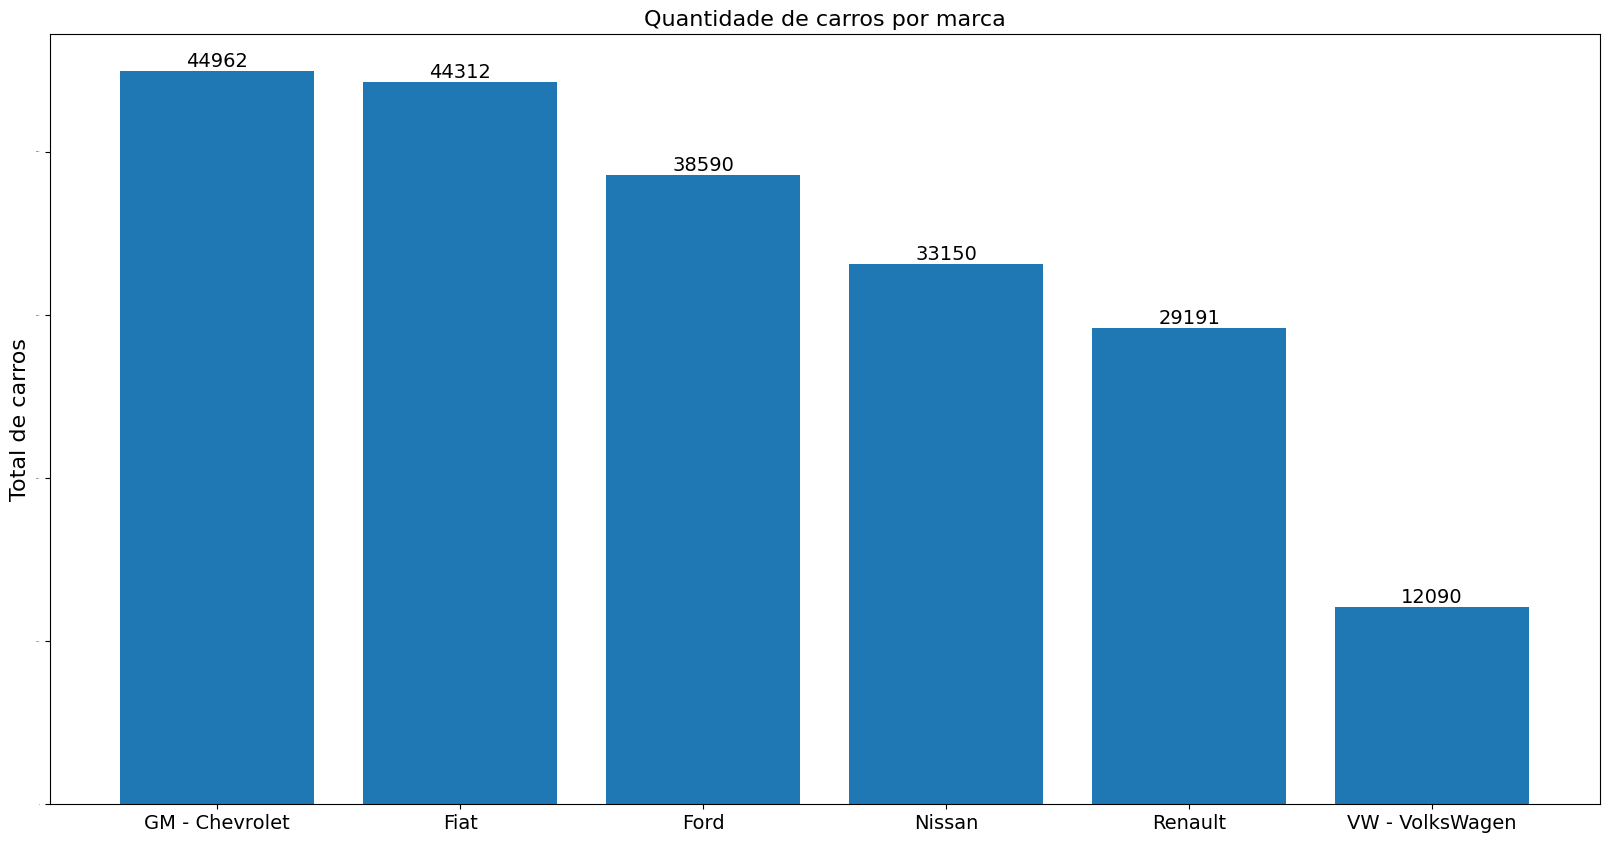

In [14]:
plt.figure(figsize=(20, 10))
grafico_1 = plt.bar(carros['brand'].unique(), carros['brand'].value_counts())
plt.title('Quantidade de carros por marca', fontsize=16)
plt.ylabel('Total de carros', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=0)

plt.bar_label(grafico_1, size = 14, label_type = "edge") 

### b. Distribution of Vehicles by Transmission Type (Gear)

[Text(0, 0, '161883'), Text(0, 0, '40412')]

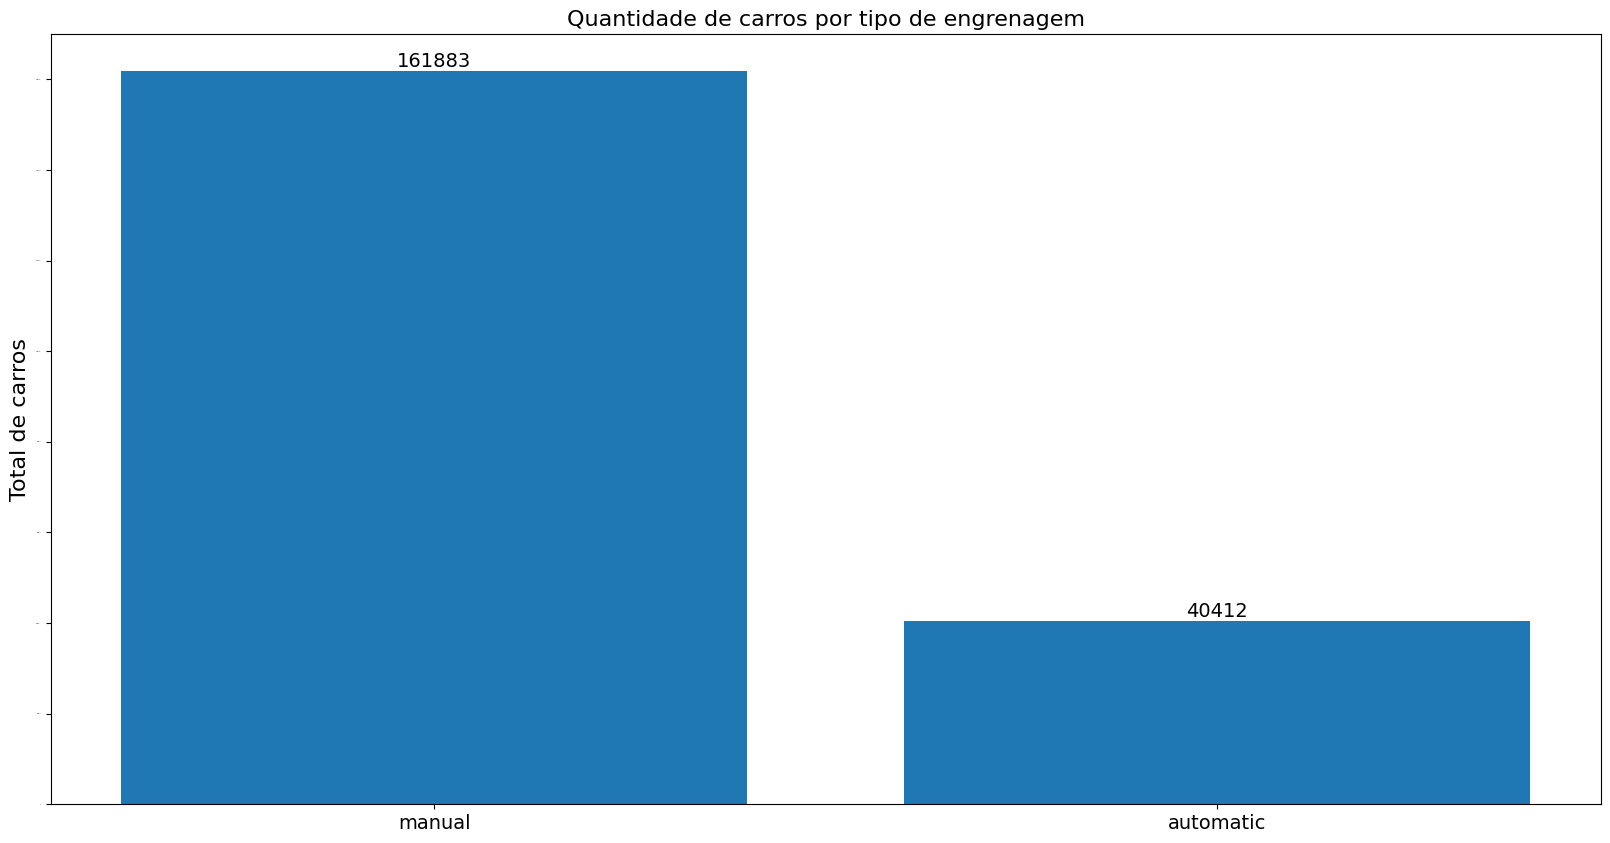

In [15]:
plt.figure(figsize=(20, 10))
grafico_1 = plt.bar(carros['gear'].unique(), carros['gear'].value_counts())
plt.title('Quantidade de carros por tipo de engrenagem', fontsize=16)
plt.ylabel('Total de carros', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=0)

plt.bar_label(grafico_1, size = 14, label_type = "edge") 

### c. Monthly Average Price Evolution in 2022

In [16]:
carros2022 = carros[carros['year_of_reference'] == 2022].groupby('month_of_reference')['avg_price_brl'].mean().reset_index()

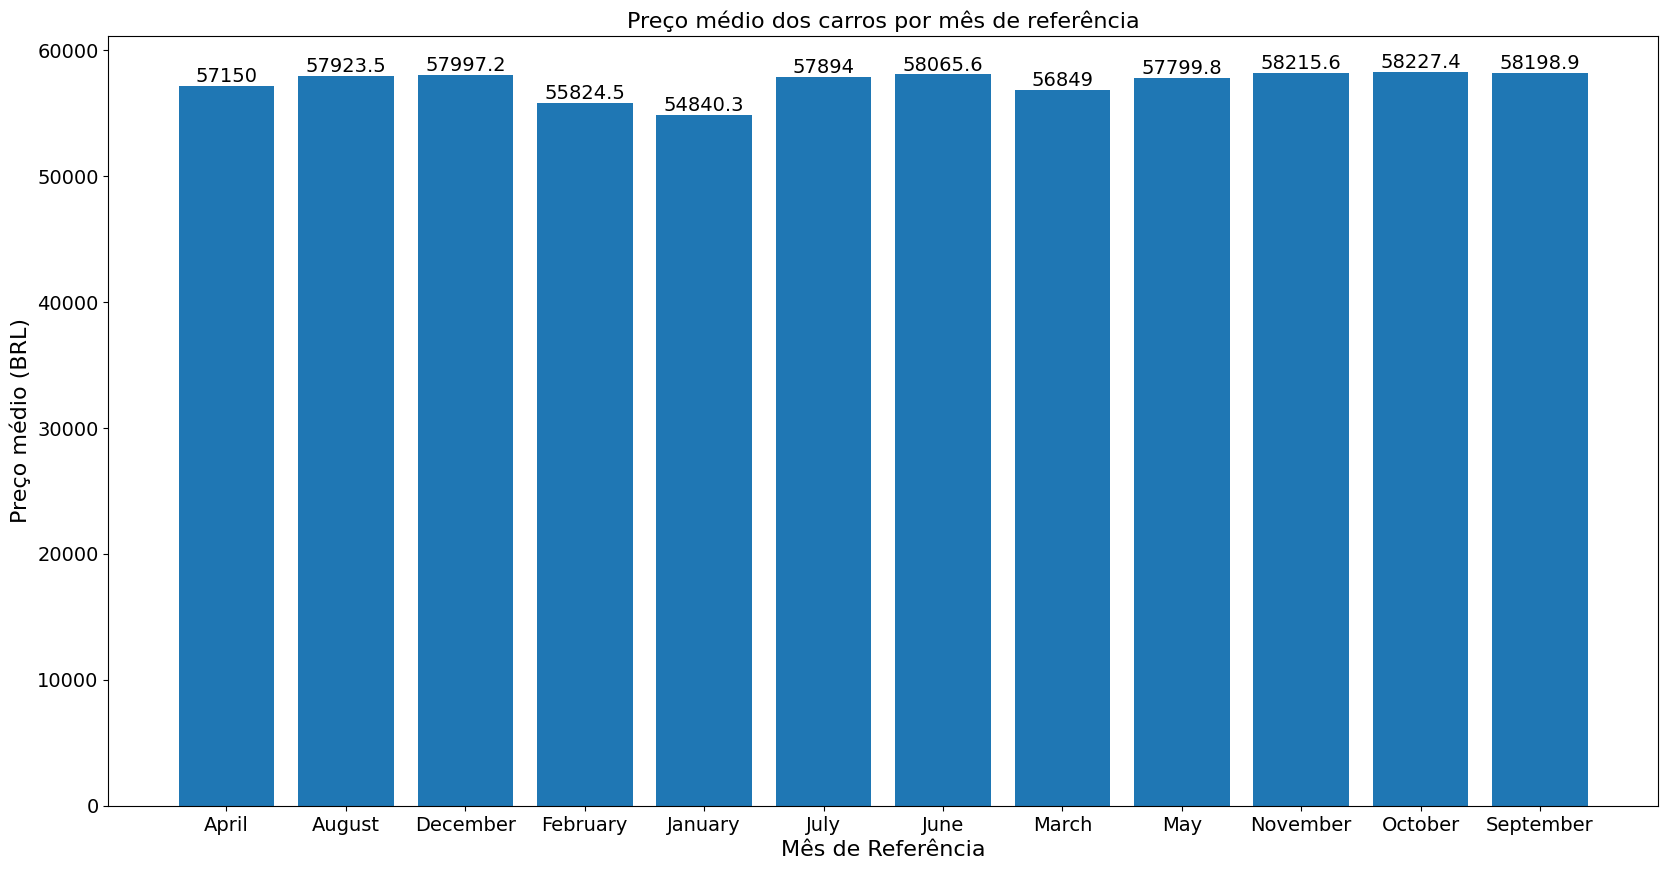

In [17]:
plt.figure(figsize=(20, 10))
grafico_1 = plt.bar(carros2022['month_of_reference'], carros2022['avg_price_brl'])
plt.title('Preço médio dos carros por mês de referência', fontsize=16)
plt.ylabel('Preço médio (BRL)', fontsize=16)
plt.xlabel('Mês de Referência', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.bar_label(grafico_1, size=14, label_type="edge")
plt.show()

### d. Average Vehicle Price by Brand and Transmission Type

In [18]:
media_preco = carros.groupby(['brand', 'gear'])['avg_price_brl'].mean().reset_index()

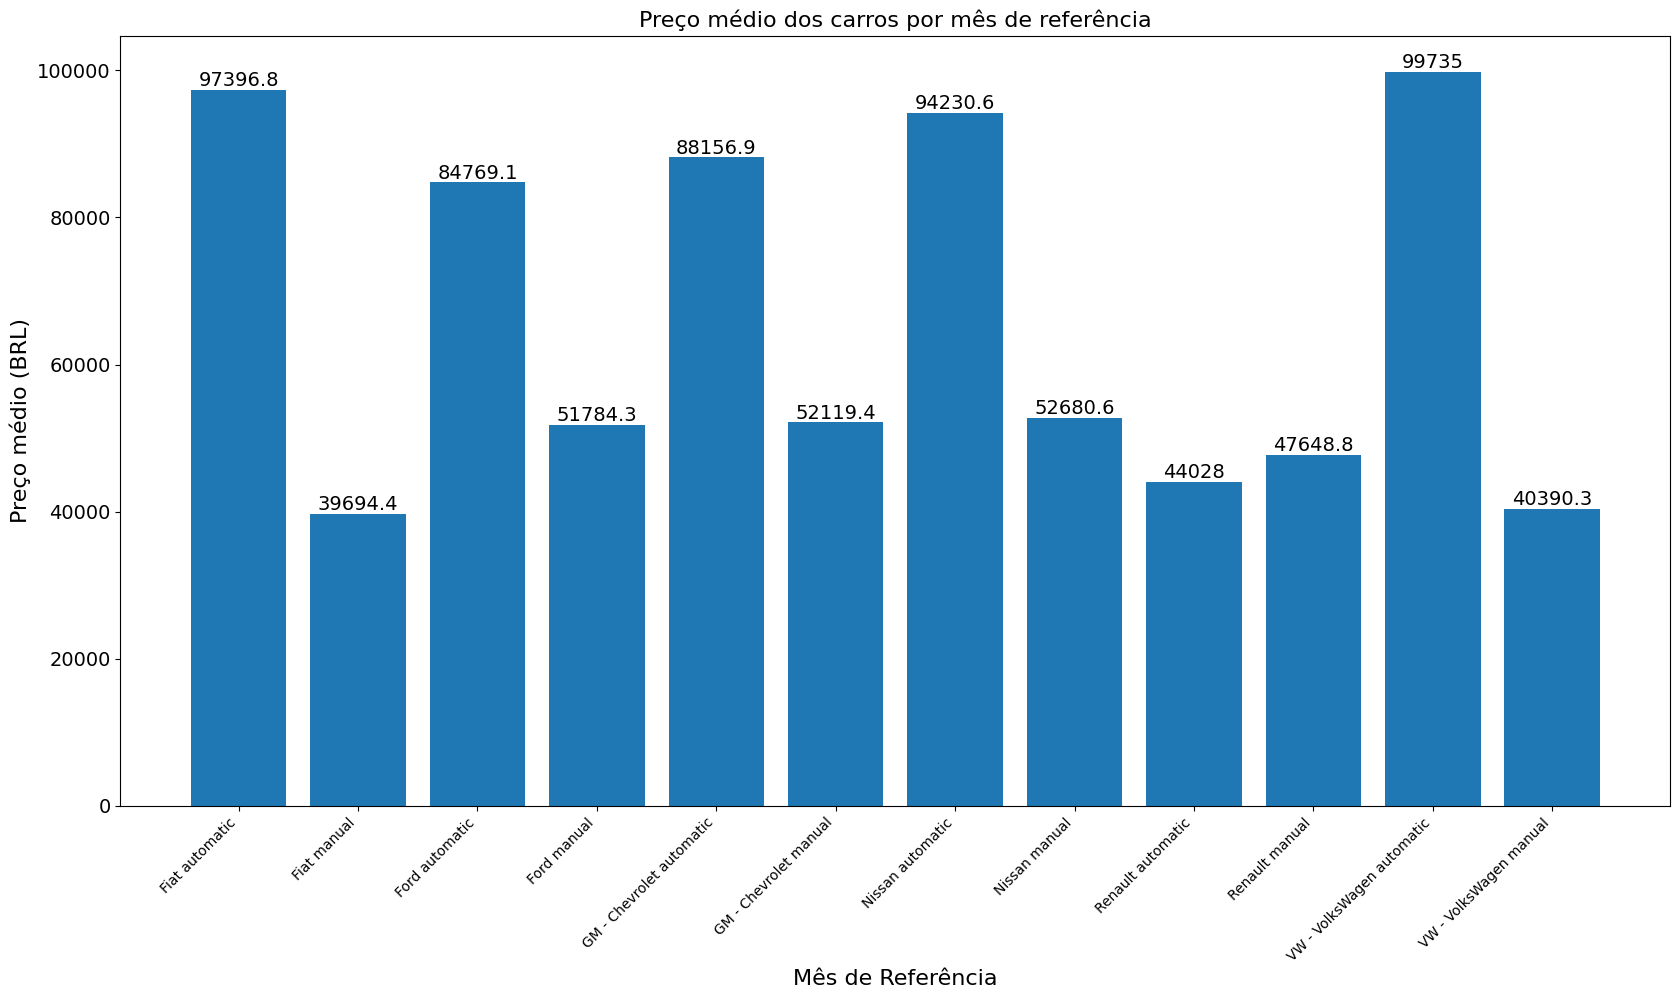

In [19]:
plt.figure(figsize=(20, 10))
grafico_1 = plt.bar(media_preco['brand']+ ' ' + media_preco['gear'], media_preco['avg_price_brl'])
plt.title('Preço médio dos carros por mês de referência', fontsize=16)
plt.ylabel('Preço médio (BRL)', fontsize=16)
plt.xlabel('Mês de Referência', fontsize=16)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=14)

plt.bar_label(grafico_1, size=14, label_type="edge")
plt.show()

### e. Insights: Transmission Type Impact on Price

Automatic vehicles average between R$ 84,769 and R$ 99,735, whereas manual vehicles average between R$ 39,694 and R$ 52,680. Automatic cars are priced almost 2x higher than manual cars across all major brands.

### f. Average Vehicle Price by Brand and Fuel Type

In [20]:
media_preco2 = carros.groupby(['brand', 'fuel'])['avg_price_brl'].mean().reset_index()

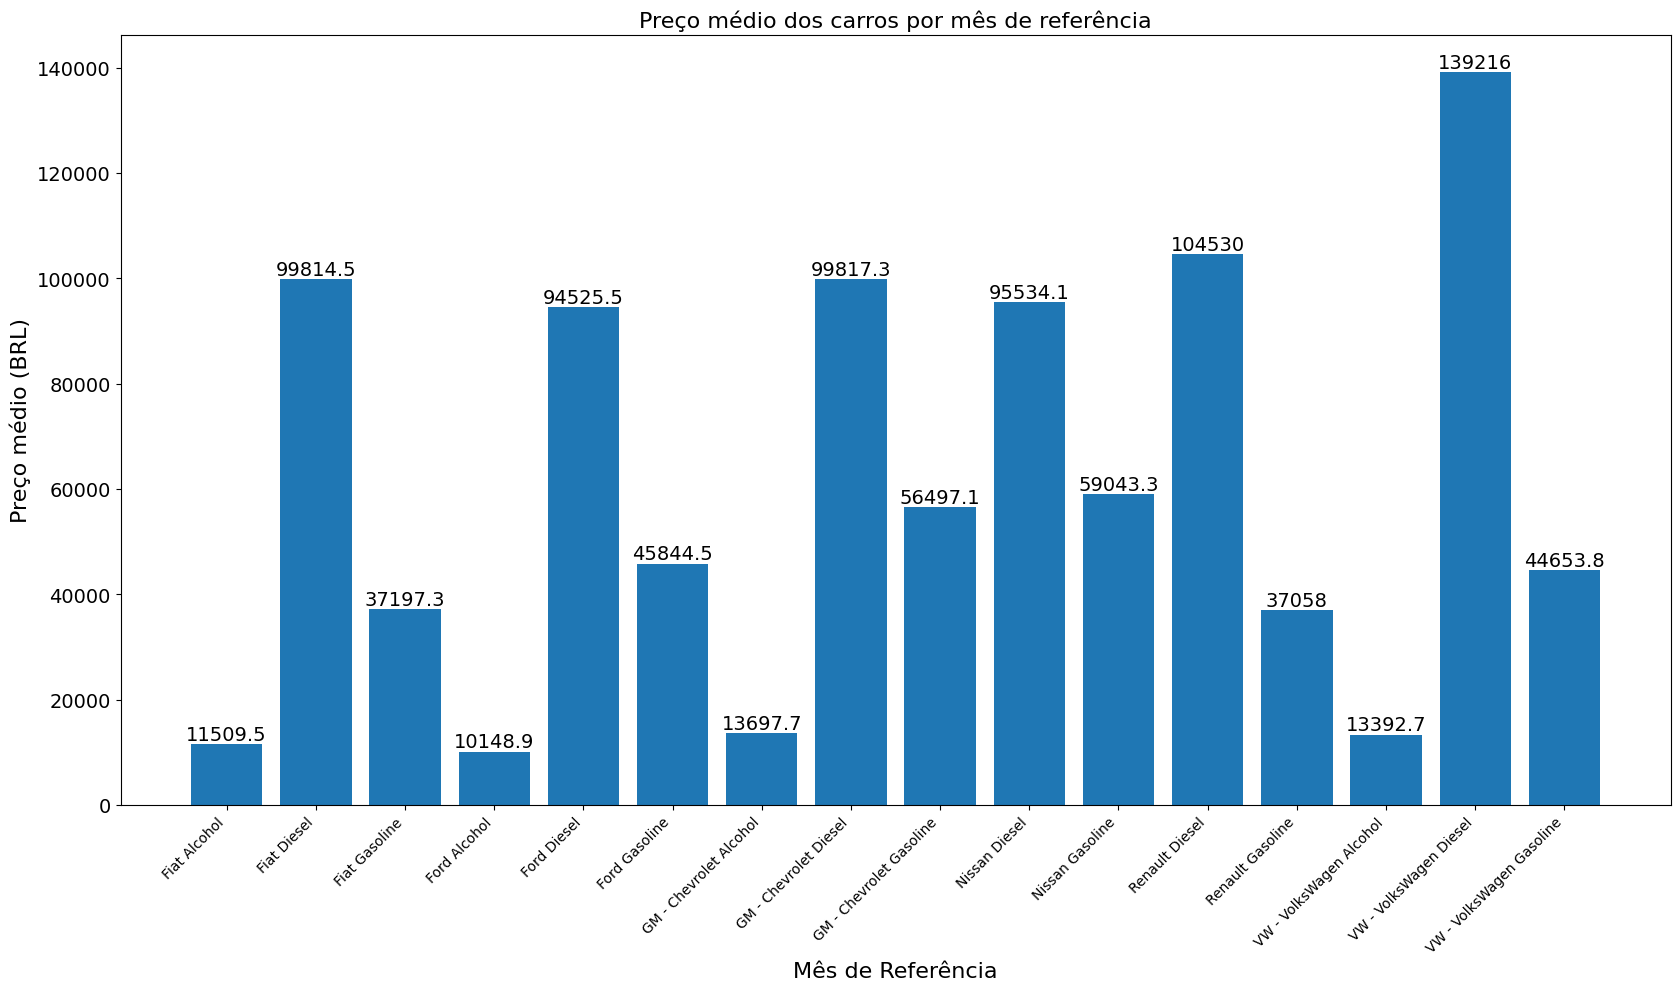

In [21]:
plt.figure(figsize=(20, 10))
grafico_1 = plt.bar(media_preco2['brand']+ ' ' + media_preco2['fuel'], media_preco2['avg_price_brl'])
plt.title('Preço médio dos carros por mês de referência', fontsize=16)
plt.ylabel('Preço médio (BRL)', fontsize=16)
plt.xlabel('Mês de Referência', fontsize=16)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=14)

plt.bar_label(grafico_1, size=14, label_type="edge")
plt.show()

### g. Insights: Fuel Type Impact on Price

Diesel vehicles command the highest market prices (ranging from ~R$ 94,525 for Ford to ~R$ 139,216 for Volkswagen). Gasoline vehicles occupy the mid-range (R$ 37k – R$ 59k), while Ethanol models display lower averages (R$ 10k – R$ 13k).

## 4. Predictive Machine Learning Models for Vehicle Price Estimation

### a. Feature Selection & Categorical Encoding for Model Input

In [22]:
#verificar os data types de cada coluna
carros.dtypes

year_of_reference     float64
month_of_reference     object
fipe_code              object
authentication         object
brand                  object
model                  object
fuel                   object
gear                   object
engine_size            object
year_model            float64
avg_price_brl         float64
dtype: object

In [23]:
# transformar as brands em número
carros['brand'] = LabelEncoder().fit_transform(carros['brand'])

In [24]:
#A variável engine_size já é um float, devemos apenas mudar o dtype

# Substituir as vírgulas por pontos (padrão norte-americano)
carros['engine_size'] = carros['engine_size'].str.replace(',', '.')

# Converter para float
carros['engine_size'] = carros['engine_size'].astype('float64')

In [25]:
#transforma fuel = Alcool em 0, fuel = Gasolina em 1 e fuel = Diesel em 2
carros['fuel'] = carros['fuel'].replace({'Alcohol': 0, 'Gasoline': 1, 'Diesel': 2})
carros[categoricas_cols].head()


,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size
0,January,004001-0,cfzlctzfwrcp,2,Corsa Wind 1.0 MPFI / EFI 2p,1,manual,1.0
1,January,004001-0,cdqwxwpw3y2p,2,Corsa Wind 1.0 MPFI / EFI 2p,1,manual,1.0
2,January,004001-0,cb1t3xwwj1xp,2,Corsa Wind 1.0 MPFI / EFI 2p,1,manual,1.0
3,January,004001-0,cb9gct6j65r0,2,Corsa Wind 1.0 MPFI / EFI 2p,0,manual,1.0
4,January,004003-7,g15wg0gbz1fx,2,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,1,manual,1.6


In [26]:
#transforma gear = automatic em 0, gear = manual em 1
carros['gear'] = carros['gear'].replace({'manual': 0, 'automatic': 1})
carros[categoricas_cols].head()

,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size
0,January,004001-0,cfzlctzfwrcp,2,Corsa Wind 1.0 MPFI / EFI 2p,1,0,1.0
1,January,004001-0,cdqwxwpw3y2p,2,Corsa Wind 1.0 MPFI / EFI 2p,1,0,1.0
2,January,004001-0,cb1t3xwwj1xp,2,Corsa Wind 1.0 MPFI / EFI 2p,1,0,1.0
3,January,004001-0,cb9gct6j65r0,2,Corsa Wind 1.0 MPFI / EFI 2p,0,0,1.0
4,January,004003-7,g15wg0gbz1fx,2,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,1,0,1.6


In [27]:
# Criar novamente as listas de colunas numéricas e categóricas

numericas_cols = [col for col in carros.columns if carros[col].dtype != 'object']
categoricas_cols = [col for col in carros.columns if carros[col].dtype == 'object']
# Criar um dataframe apenas com as colunas numéricas
dados_num = carros[numericas_cols]
dados_num.head()

,year_of_reference,brand,fuel,gear,engine_size,year_model,avg_price_brl
0,2021.0,2,1,0,1.0,2002.0,9162.0
1,2021.0,2,1,0,1.0,2001.0,8832.0
2,2021.0,2,1,0,1.0,2000.0,8388.0
3,2021.0,2,0,0,1.0,2000.0,8453.0
4,2021.0,2,1,0,1.6,2001.0,12525.0


Engine size (), fuel type (), and transmission type () were encoded into numerical representations, as they strongly correlate with vehicle valuation.

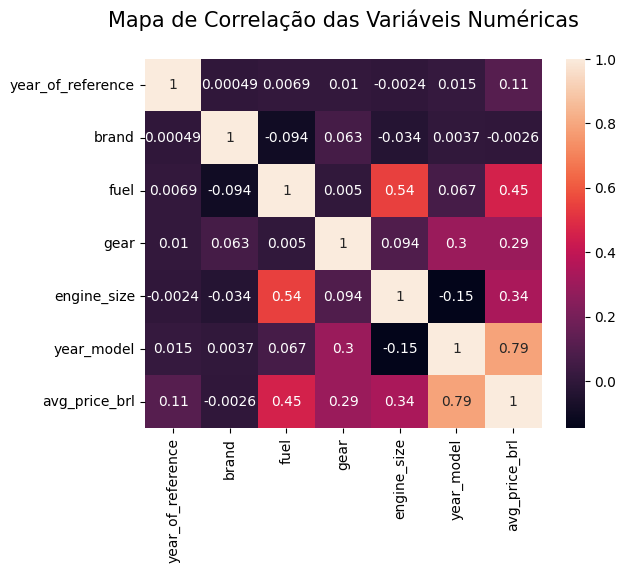

In [28]:
# Mapa de correlação das variáveis numéricas com variável Target
sns.heatmap(dados_num.corr("spearman"), annot = True)
plt.title("Mapa de Correlação das Variáveis Numéricas\n", fontsize = 15)
plt.show()

In [29]:
# Variável X contém apenas variáveis numéricas de interesse para a análise, excluindo a variável target 
X = dados_num.drop(['avg_price_brl'],axis = 1)
X.head()

,year_of_reference,brand,fuel,gear,engine_size,year_model
0,2021.0,2,1,0,1.0,2002.0
1,2021.0,2,1,0,1.0,2001.0
2,2021.0,2,1,0,1.0,2000.0
3,2021.0,2,0,0,1.0,2000.0
4,2021.0,2,1,0,1.6,2001.0


In [30]:
# Variável Y contém apenas a variável target
Y = dados_num['avg_price_brl']
Y.head()

0     9162.0
1     8832.0
2     8388.0
3     8453.0
4    12525.0
Name: avg_price_brl, dtype: float64

### b. Train-Test Split (75% Training / 25% Testing)

In [31]:
# Divisão: 25% dos dados são de teste e 75% de treinamento
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 42)

In [32]:
# Observando os dados de treinamento
print(X_train.shape)
X_train.head(1)

(151721, 6)


,year_of_reference,brand,fuel,gear,engine_size,year_model
156364,2022.0,0,2,0,2.3,2020.0


In [33]:
# Observando os dados de teste
print(X_test.shape)
X_test.head(1)

(50574, 6)


,year_of_reference,brand,fuel,gear,engine_size,year_model
180633,2022.0,0,1,0,1.6,2015.0


In [34]:
# Observando a variável target
Y_test.head()

180633    42595.0
13130     10989.0
163315     9087.0
121464    26965.0
14044     57102.0
Name: avg_price_brl, dtype: float64

### c. Train Machine Learning Regressors (Random Forest & XGBoost)

In [35]:
# Algoritmo Random Forest, sem especificar nenhum parâmetro (número de árvores, número de ramificações, etc)
model_rf = RandomForestRegressor()
model_rf_parametros = RandomForestRegressor(max_depth=29, min_samples_leaf=32, min_samples_split=28,
                       n_estimators=208, random_state=43)
model_xgboost = XGBRegressor()

In [36]:
# Ajuste do modelo, de acordo com as variáveis de treinamento
model_rf.fit(X_train, Y_train)
model_rf_parametros.fit(X_train, Y_train)
model_xgboost.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

### d. Generate Model Predictions on Test Data

In [37]:
# Predição dos preço médio com base nos dados de teste
valores_preditos_rf = model_rf.predict(X_test)
valores_preditos_rf_par = model_rf_parametros.predict(X_test)
valores_preditos_xgboost = model_xgboost.predict(X_test)

### e. Feature Importance Analysis

In [38]:
# Analisando a importância das variáveis - RF
model_rf.feature_importances_
feature_importances = pd.DataFrame(model_rf.feature_importances_, index = X_train.columns, columns=['importance']).sort_values('importance', ascending = False)
feature_importances

,importance
engine_size,0.438761
year_model,0.395620
fuel,0.089405
gear,0.037236
brand,0.025486
year_of_reference,0.013491


In [39]:
# Analisando a importância das variáveis - RF com parâmetros
model_rf_parametros.feature_importances_
feature_importances = pd.DataFrame(model_rf_parametros.feature_importances_, index = X_train.columns, columns=['importance']).sort_values('importance', ascending = False)
feature_importances

,importance
engine_size,0.437338
year_model,0.412024
fuel,0.092810
gear,0.026048
brand,0.020394
year_of_reference,0.011386


In [40]:
# Analisando a importância das variáveis - XGBoost
model_xgboost.feature_importances_
feature_importances = pd.DataFrame(model_xgboost.feature_importances_, index = X_train.columns, columns=['importance']).sort_values('importance', ascending = False)
feature_importances

,importance
fuel,0.301133
engine_size,0.300491
year_model,0.232414
gear,0.117873
brand,0.031723
year_of_reference,0.016365


### f. Insights: Feature Importance Comparison

Engine size (), manufacturing year (), and fuel type () emerged as the top key drivers of vehicle price across both Random Forest and XGBoost architectures.

### g. Model Evaluation & Comparison (MSE, MAE, R² Score)

In [41]:
# medindo a acurácia do random forest sem parâmetros
mse = mean_squared_error(Y_test, valores_preditos_rf)
mae = mean_absolute_error(Y_test, valores_preditos_rf)
r2 = r2_score(Y_test, valores_preditos_rf)
print(f'MSE: {mse},  MAE: {mae}, R²: {r2}')

MSE: 106694746.60878642,  MAE: 5599.608691294658, R²: 0.9603550557233311


In [42]:
# medindo a acurácia do random forest com parâmetros
mse = mean_squared_error(Y_test, valores_preditos_rf_par)
mae = mean_absolute_error(Y_test, valores_preditos_rf_par)
r2 = r2_score(Y_test, valores_preditos_rf_par)
print(f'MSE: {mse},  MAE: {mae}, R²: {r2}')

MSE: 194605076.308143,  MAE: 6340.522713313539, R²: 0.9276899036605625


In [43]:
# medindo a acurácia do XGBoost
mse = mean_squared_error(Y_test, valores_preditos_xgboost)
mae = mean_absolute_error(Y_test, valores_preditos_xgboost)
r2 = r2_score(Y_test, valores_preditos_xgboost)
print(f'MSE: {mse},  MAE: {mae}, R²: {r2}')

MSE: 108591038.5960788,  MAE: 5694.641060015784, R²: 0.9596504438042068


### h. Final Model Selection & Performance Conclusion

Evaluating models via Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score, the **Random Forest Regressor (Default Parameters)** yielded the highest accuracy with **R² Score = 0.96 (96.0% variance explained)** and lowest prediction errors.